# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

In [2]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

for nombre, df in [('2018', d18), ('2022', d22), ('2026', d26)]:
    print(f"--- Mundial {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas ---")
    print(df.head(3))
    print()

--- Mundial 2018: 50 filas x 16 columnas ---
  ID Partido   Año            Fase    Grupo Jornada       Fecha   Hora  \
0  M-2018-01  2018  Fase de grupos  Grupo A       1  2018-06-14  18:00   
1  M-2018-02  2018     GROUP STAGE        A       1  15/06/2018  17:00   
2  M-2018-03  2018          grupos  group-b       1  06/15/2018  18:00   

  Equipo Local Equipo Visitante Goles Local Goles Visitante Marcador  \
0       russia              KSA     5 goles             NaN      5-0   
1        Egypt          Uruguay           0               1      0–1   
2      Morocco       Iran, I.R.           0               1    0 : 1   

  Anfitrión Local             Estadio            Ciudad  \
0              Sí    Luzhniki Stadium            Moscow   
1               0     Central Stadium     Yekaterinburg   
2           FALSE  Krestovsky Stadium  Saint Petersburg   

                                  Fuente  
0  https://github.com/jfjelstul/worldcup  
1  https://github.com/jfjelstul/worldcup  
2  

## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [3]:
def perfil(df, nombre):
    print(f"=== Perfil {nombre} ===")
    print("Dimensiones:", df.shape)
    print("Columnas:", list(df.columns))
    print("\nValores nulos por columna:")
    print(df.isna().sum())
    id_col = df.columns[0]
    print(f"\nFilas duplicadas (idénticas en todas las columnas): {df.duplicated().sum()}")
    print(f"IDs duplicados en '{id_col}': {df[id_col].duplicated().sum()}")
    for col in df.columns:
        if 'group' in col.lower() or 'grp' in col.lower() or col.lower() == 'grupo':
            print(f"\nValores únicos en '{col}':", sorted(df[col].dropna().unique().tolist()))
        if 'stage' in col.lower() or 'fase' in col.lower() or col.lower() == 'round':
            print(f"Valores únicos en '{col}':", sorted(df[col].dropna().unique().tolist()))
    # goles que no son directamente convertibles a número
    for col in df.columns:
        if 'score' in col.lower() or 'gol' in col.lower() or col in ('HG', 'AG'):
            no_numericos = df[col].dropna()[~df[col].dropna().str.match(r'^-?\d+$')]
            if len(no_numericos):
                print(f"\nValores no numéricos en '{col}':", sorted(no_numericos.unique().tolist()))
    print("\n")

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')

=== Perfil 2018 ===
Dimensiones: (50, 16)
Columnas: ['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']

Valores nulos por columna:
ID Partido          0
Año                 0
Fase                0
Grupo               1
Jornada             0
Fecha               0
Hora                0
Equipo Local        0
Equipo Visitante    0
Goles Local         0
Goles Visitante     3
Marcador            1
Anfitrión Local     0
Estadio             0
Ciudad              0
Fuente              0
dtype: int64

Filas duplicadas (idénticas en todas las columnas): 2
IDs duplicados en 'ID Partido': 2
Valores únicos en 'Fase': ['1ra fase', 'Fase de grupos', 'GROUP STAGE', 'grupos']

Valores únicos en 'Grupo': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Grupo A', 'Grupo B', 'Grupo C', 'Grupo D', 'Grupo E', 'Grupo F', 'Grupo G', 'Grupo H', 'group-a', 'group-b', 'group-c', 

## Unificar nombres de columnas

In [4]:
rename_maps = {
    2018: {
        'ID Partido': 'partido_id', 'Año': 'mundial', 'Fase': 'fase', 'Grupo': 'grupo',
        'Jornada': 'jornada', 'Fecha': 'fecha', 'Equipo Local': 'equipo_local',
        'Equipo Visitante': 'equipo_visitante', 'Goles Local': 'goles_local',
        'Goles Visitante': 'goles_visitante', 'Marcador': 'marcador',
        'Anfitrión Local': 'local_es_anfitrion', 'Fuente': 'fuente',
    },
    2022: {
        'match_id': 'partido_id', 'WorldCup': 'mundial', 'stage': 'fase', 'group_name': 'grupo',
        'match_day': 'jornada', 'date': 'fecha', 'local': 'equipo_local', 'visitor': 'equipo_visitante',
        'home_score': 'goles_local', 'away_score': 'goles_visitante', 'score_text': 'marcador',
        'home_host': 'local_es_anfitrion', 'source_url': 'fuente',
    },
    2026: {
        'match': 'partido_id', 'wc': 'mundial', 'round': 'fase', 'grp': 'grupo', 'md': 'jornada',
        'played_on': 'fecha', 'home': 'equipo_local', 'away': 'equipo_visitante',
        'HG': 'goles_local', 'AG': 'goles_visitante', 'result_raw': 'marcador',
        'host_h': 'local_es_anfitrion', 'host_a': 'visitante_es_anfitrion', 'source': 'fuente',
    },
}

# Esquema canónico mínimo:
columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]

print('2018 no tiene columna para visitante_es_anfitrion: se crea con valor "No" salvo que el local sea anfitrión.')
print('2022 tampoco trae visitante_es_anfitrion explícita (se infiere igual que en 2018).')

2018 no tiene columna para visitante_es_anfitrion: se crea con valor "No" salvo que el local sea anfitrión.
2022 tampoco trae visitante_es_anfitrion explícita (se infiere igual que en 2018).


## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [5]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    """Normaliza un texto: sin acentos, minúsculas, sin signos, espacios colapsados.
    Se usa solo como CLAVE de búsqueda; el nombre que se muestra conserva acentos."""
    if valor is None or (isinstance(valor, float) and pd.isna(valor)):
        return ''
    texto = str(valor).strip().lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r'[^a-z0-9]+', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

catalogo['clave'] = catalogo['Variante'].apply(clave_texto)
mapa_equipos = dict(zip(catalogo['clave'], catalogo['Nombre canónico']))

def normalizar_equipo(valor):
    clave = clave_texto(valor)
    if clave in mapa_equipos:
        return mapa_equipos[clave]
    return str(valor).strip() if valor is not None else np.nan

print(f"Catálogo cargado: {len(catalogo)} variantes -> {catalogo['Nombre canónico'].nunique()} equipos canónicos.")
print(normalizar_equipo('KSA'), '|', normalizar_equipo('Korea Republic'), '|', normalizar_equipo('Côte d’Ivoire'))

Catálogo cargado: 95 variantes -> 58 equipos canónicos.
Saudi Arabia | South Korea | Ivory Coast


## Fechas, grupos, booleanos y marcadores

In [6]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

MESES = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
FORMATOS_FECHA = ['%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y', '%d-%m-%y', '%m/%d/%y']

def _origen_excel(numero):
    # Excel (sistema 1900) cuenta los días desde el 30-dic-1899.
    from datetime import date, timedelta
    origen = date(1899, 12, 30)
    return origen + timedelta(days=int(numero))

def convertir_fecha(valor, mundial):
    # 1. reconoce seriales de Excel; 2. prueba varios formatos; 3. elige una
    # fecha dentro del rango del torneo (así se descartan interpretaciones erróneas).
    ini, fin = pd.to_datetime(rangos[mundial][0]), pd.to_datetime(rangos[mundial][1])
    if valor is None:
        return pd.NaT
    texto = str(valor).strip()
    if texto == '' or texto.lower() in ('n/d', 'n/a', 's/d', 'nan', 'none'):
        return pd.NaT

    if re.fullmatch(r'\d{4,6}', texto):
        try:
            f = pd.Timestamp(_origen_excel(int(texto)))
            if ini <= f <= fin:
                return f
        except Exception:
            pass

    m = re.match(r'([A-Za-z]{3})[a-z]*\s+(\d{1,2}),?\s+(\d{4})', texto)
    if m:
        from datetime import date
        mes = MESES.get(m.group(1).lower()[:3])
        if mes:
            try:
                f = pd.Timestamp(date(int(m.group(3)), mes, int(m.group(2))))
                if ini <= f <= fin:
                    return f
            except Exception:
                pass

    for fmt in FORMATOS_FECHA:
        try:
            f = pd.Timestamp(pd.to_datetime(texto, format=fmt))
            if ini <= f <= fin:
                return f
        except Exception:
            continue

    try:
        f = pd.to_datetime(texto, dayfirst=True, errors='coerce')
        if pd.notna(f) and ini <= f <= fin:
            return f
    except Exception:
        pass
    return pd.NaT


def extraer_numero(valor):
    # devuelve el primer entero >= 0 encontrado, o NaN
    if valor is None:
        return np.nan
    texto = str(valor).strip().lower()
    if texto in ('', 's/d', 'n/a', 'n/d', 'nan', 'none'):
        return np.nan
    m = re.search(r'-?\d+', texto)
    if not m:
        return np.nan
    n = int(m.group())
    return n if n >= 0 else np.nan


def separar_marcador(valor):
    # acepta -, –, —, :, x o X
    if valor is None:
        return np.nan, np.nan
    texto = str(valor).strip().lower()
    if texto in ('', 'sin dato', 's/d', 'n/a', 'nan', 'none'):
        return np.nan, np.nan
    texto = texto.replace('–', '-').replace('—', '-').replace(':', '-')
    texto = re.sub(r'\s*x\s*', '-', texto)
    partes = [p.strip() for p in texto.split('-') if p.strip() != '']
    if len(partes) != 2:
        return np.nan, np.nan
    try:
        a, b = int(partes[0]), int(partes[1])
    except ValueError:
        return np.nan, np.nan
    if a < 0 or b < 0:
        return np.nan, np.nan
    return a, b


def normalizar_grupo(valor):
    # extrae una letra A-L
    if valor is None:
        return np.nan
    texto = str(valor).strip().upper()
    if texto in ('', 'S/D', 'NAN', 'NONE'):
        return np.nan
    texto_sep = re.sub(r'[-_]', ' ', texto)
    m = re.search(r'\b([A-L])\b', texto_sep)
    return m.group(1) if m else np.nan


def normalizar_booleano(valor):
    # reconoce Sí, 1, TRUE, si, etc.
    if valor is None:
        return 'No'
    texto = str(valor).strip().lower()
    return 'Sí' if texto in ('sí', 'si', 'true', '1', 'yes', 'x') else 'No'

print(convertir_fecha('46187', 2026), '| serial de Excel reconocido')
print(separar_marcador('2 x 1'), '| separador x reconocido')
print(normalizar_grupo('group-b'), normalizar_grupo('Grupo H'))
print(normalizar_booleano('TRUE'), normalizar_booleano('no'))

2026-06-14 00:00:00 | serial de Excel reconocido
(2, 1) | separador x reconocido
B H
Sí No


## Función de limpieza reproducible

In [7]:
def limpiar_mundial(df_raw, mundial, bitacora=None):
    df = df_raw.rename(columns=rename_maps[mundial]).copy()
    for c in columnas_base:
        if c not in df.columns:
            df[c] = np.nan

    df['mundial'] = mundial
    df['fase'] = 'Fase de grupos'
    df['grupo'] = df['grupo'].apply(normalizar_grupo)
    df['jornada'] = pd.to_numeric(df['jornada'], errors='coerce').astype('Int64')
    df['fecha'] = df['fecha'].apply(lambda v: convertir_fecha(v, mundial))

    df['equipo_local'] = df['equipo_local'].apply(normalizar_equipo)
    df['equipo_visitante'] = df['equipo_visitante'].apply(normalizar_equipo)

    df['local_es_anfitrion'] = df['local_es_anfitrion'].apply(normalizar_booleano)
    df['visitante_es_anfitrion'] = df['visitante_es_anfitrion'].apply(normalizar_booleano)

    # Reparar goles con el marcador (regla del Paso 7 de la guía)
    gl_directo = df['goles_local'].apply(extraer_numero)
    gv_directo = df['goles_visitante'].apply(extraer_numero)
    marcador_par = df['marcador'].apply(separar_marcador)
    gl_marcador = marcador_par.apply(lambda t: t[0])
    gv_marcador = marcador_par.apply(lambda t: t[1])

    conflictos = 0
    goles_local_final, goles_visitante_final = [], []
    for gld, gvd, glm, gvm in zip(gl_directo, gv_directo, gl_marcador, gv_marcador):
        if pd.notna(glm) and pd.notna(gvm):
            if pd.notna(gld) and pd.notna(gvd) and (gld != glm or gvd != gvm):
                conflictos += 1  # se resuelve a favor del marcador; queda documentado
            goles_local_final.append(glm); goles_visitante_final.append(gvm)
        elif pd.notna(gld) and pd.notna(gvd):
            goles_local_final.append(gld); goles_visitante_final.append(gvd)
        else:
            goles_local_final.append(np.nan); goles_visitante_final.append(np.nan)

    df['goles_local'] = goles_local_final
    df['goles_visitante'] = goles_visitante_final
    df['marcador'] = df.apply(
        lambda r: f"{int(r['goles_local'])}-{int(r['goles_visitante'])}"
        if pd.notna(r['goles_local']) and pd.notna(r['goles_visitante']) else np.nan, axis=1)

    if bitacora is not None:
        bitacora['conflictos_marcador'] = bitacora.get('conflictos_marcador', 0) + conflictos

    # Inferir grupos faltantes usando el grupo ya conocido del mismo equipo
    mapa_equipo_grupo = {}
    for _, r in df.dropna(subset=['grupo']).iterrows():
        mapa_equipo_grupo.setdefault(r['equipo_local'], r['grupo'])
        mapa_equipo_grupo.setdefault(r['equipo_visitante'], r['grupo'])

    def _grupo_por_equipo(row):
        if pd.notna(row['grupo']):
            return row['grupo']
        return mapa_equipo_grupo.get(row['equipo_local']) or mapa_equipo_grupo.get(row['equipo_visitante'])

    df['grupo'] = df.apply(_grupo_por_equipo, axis=1)

    # Fechas no interpretables: se imputan con la mediana de la misma jornada
    # (en fase de grupos los partidos de una jornada caen en fechas cercanas). Se documenta.
    fechas_imputadas = df['fecha'].isna().sum()
    if bitacora is not None:
        bitacora['fechas_imputadas'] = bitacora.get('fechas_imputadas', 0) + fechas_imputadas
    df['fecha'] = df['fecha'].fillna(df.groupby('jornada')['fecha'].transform('median'))

    # Eliminar duplicados por partido_id, conservando la primera aparición
    dup_antes = df['partido_id'].duplicated().sum()
    df = df.drop_duplicates(subset='partido_id', keep='first').reset_index(drop=True)
    if bitacora is not None:
        bitacora['duplicados_eliminados'] = bitacora.get('duplicados_eliminados', 0) + dup_antes

    # Columnas derivadas
    def _resultado(row):
        if pd.isna(row['goles_local']) or pd.isna(row['goles_visitante']):
            return np.nan
        if row['goles_local'] > row['goles_visitante']:
            return 'Gana'
        if row['goles_local'] == row['goles_visitante']:
            return 'Empata'
        return 'Pierde'

    df['resultado_local'] = df.apply(_resultado, axis=1)
    df['goles_totales'] = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
    df['puntos_local'] = df['resultado_local'].map({'Gana': 3, 'Empata': 1, 'Pierde': 0})
    df['puntos_visitante'] = df['resultado_local'].map({'Gana': 0, 'Empata': 1, 'Pierde': 3})

    columnas_finales = columnas_base + ['resultado_local', 'goles_totales', 'diferencia_goles', 'puntos_local', 'puntos_visitante']
    return df[columnas_finales]

bitacora = {}
limpio18 = limpiar_mundial(d18, 2018, bitacora)
limpio22 = limpiar_mundial(d22, 2022, bitacora)
limpio26 = limpiar_mundial(d26, 2026, bitacora)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)
partidos = partidos.sort_values(['mundial', 'jornada', 'fecha', 'partido_id']).reset_index(drop=True)

print('Bitácora de decisiones aplicadas:', bitacora)
print('Partidos por mundial:')
print(partidos.groupby('mundial').size())

Bitácora de decisiones aplicadas: {'conflictos_marcador': 0, 'fechas_imputadas': np.int64(2), 'duplicados_eliminados': np.int64(8)}
Partidos por mundial:
mundial
2018    48
2022    48
2026    72
dtype: int64


## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [8]:
# Verificaciones obligatorias
esperado = {2018: 48, 2022: 48, 2026: 72}
conteo = partidos.groupby('mundial').size().to_dict()
assert conteo == esperado, f"Conteo por mundial incorrecto: {conteo}"
print("OK: 48/48/72 partidos por mundial.")

assert len(partidos) == 168, "El total debe ser 168 partidos."
print("OK: 168 partidos en total.")

assert partidos['partido_id'].duplicated().sum() == 0, "Hay IDs de partido duplicados."
print("OK: cero duplicados por partido_id.")

assert (partidos['goles_local'] >= 0).all() and (partidos['goles_visitante'] >= 0).all(), "Hay goles negativos."
print("OK: cero goles negativos.")

cols_criticas = ['equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'grupo']
nulos = partidos[cols_criticas].isna().sum()
assert nulos.sum() == 0, f"Hay nulos en columnas críticas:\n{nulos}"
print("OK: cero nulos en equipo, goles y grupo.")

marcador_calc = partidos['goles_local'].astype(int).astype(str) + '-' + partidos['goles_visitante'].astype(int).astype(str)
assert (marcador_calc == partidos['marcador']).all(), "El marcador no es consistente con los goles."
print("OK: marcador consistente con los goles en el 100% de los partidos.")

assert partidos.groupby('mundial')['fecha'].apply(lambda s: pd.api.types.is_datetime64_any_dtype(s)).all()
print("OK: todas las fechas son fechas válidas (dentro del rango del torneo).")

print("\nTodas las validaciones pasaron correctamente. La base integrada tiene 168 partidos.")

OK: 48/48/72 partidos por mundial.
OK: 168 partidos en total.
OK: cero duplicados por partido_id.
OK: cero goles negativos.
OK: cero nulos en equipo, goles y grupo.
OK: marcador consistente con los goles en el 100% de los partidos.
OK: todas las fechas son fechas válidas (dentro del rango del torneo).

Todas las validaciones pasaron correctamente. La base integrada tiene 168 partidos.


## Comparación de los Mundiales

   mundial  partidos  goles  empates  goles_por_partido  pct_empates
0     2018        48  122.0        9           2.541667     0.187500
1     2022        48  120.0       10           2.500000     0.208333
2     2026        72  215.0       20           2.986111     0.277778

Nota: 2026 tiene más partidos (72) que 2018 y 2022 (48 cada uno), por lo que
comparar solo goles totales exagera la diferencia. La tasa (goles/partido) es comparable entre torneos.


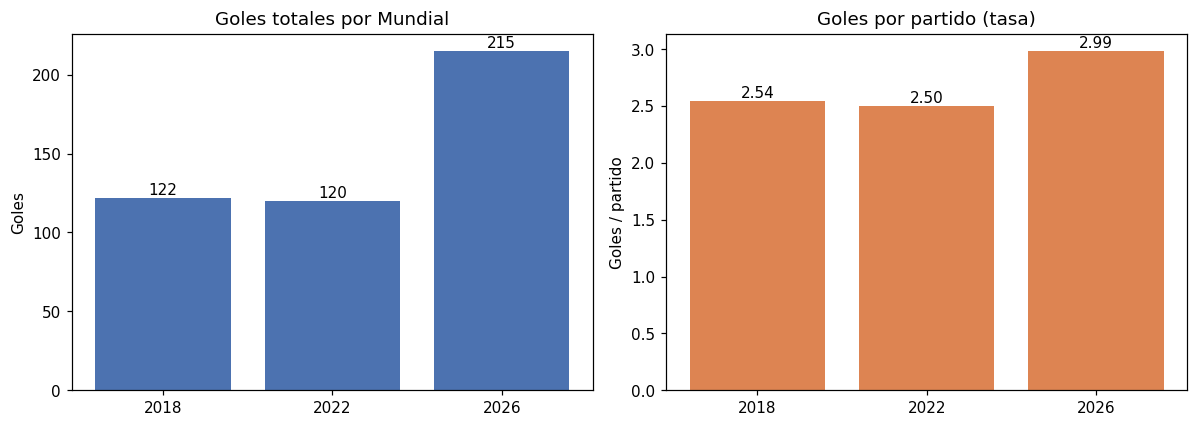

In [9]:
comparacion = partidos.groupby('mundial').agg(
    partidos=('partido_id', 'count'),
    goles=('goles_totales', 'sum'),
    empates=('resultado_local', lambda s: (s == 'Empata').sum()),
).reset_index()
comparacion['goles_por_partido'] = comparacion['goles'] / comparacion['partidos']
comparacion['pct_empates'] = comparacion['empates'] / comparacion['partidos']
print(comparacion)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(comparacion['mundial'].astype(str), comparacion['goles'], color='#4C72B0', label='Goles totales')
axes[0].set_title('Goles totales por Mundial')
axes[0].set_ylabel('Goles')
for i, v in enumerate(comparacion['goles']):
    axes[0].text(i, v + 2, str(int(v)), ha='center')

axes[1].bar(comparacion['mundial'].astype(str), comparacion['goles_por_partido'], color='#DD8452')
axes[1].set_title('Goles por partido (tasa)')
axes[1].set_ylabel('Goles / partido')
for i, v in enumerate(comparacion['goles_por_partido']):
    axes[1].text(i, v + 0.03, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

print("\nNota: 2026 tiene más partidos (72) que 2018 y 2022 (48 cada uno), por lo que")
print("comparar solo goles totales exagera la diferencia. La tasa (goles/partido) es comparable entre torneos.")

## Tabla por equipo

In [10]:
locales = partidos.rename(columns={
    'equipo_local': 'equipo', 'equipo_visitante': 'rival',
    'goles_local': 'gf', 'goles_visitante': 'gc', 'puntos_local': 'pts'})[
    ['mundial', 'equipo', 'gf', 'gc', 'pts']]
locales['resultado'] = np.where(locales['pts'] == 3, 'G', np.where(locales['pts'] == 1, 'E', 'P'))

visitantes = partidos.rename(columns={
    'equipo_visitante': 'equipo', 'equipo_local': 'rival',
    'goles_visitante': 'gf', 'goles_local': 'gc', 'puntos_visitante': 'pts'})[
    ['mundial', 'equipo', 'gf', 'gc', 'pts']]
visitantes['resultado'] = np.where(visitantes['pts'] == 3, 'G', np.where(visitantes['pts'] == 1, 'E', 'P'))

apariciones = pd.concat([locales, visitantes], ignore_index=True)

tabla = apariciones.groupby(['mundial', 'equipo']).agg(
    PJ=('pts', 'count'),
    PG=('resultado', lambda s: (s == 'G').sum()),
    PE=('resultado', lambda s: (s == 'E').sum()),
    PP=('resultado', lambda s: (s == 'P').sum()),
    GF=('gf', 'sum'), GC=('gc', 'sum'), PTS=('pts', 'sum'),
).reset_index()
tabla['DG'] = tabla['GF'] - tabla['GC']
tabla['PTS_POR_PARTIDO'] = tabla['PTS'] / tabla['PJ']
tabla = tabla.sort_values(['mundial', 'PTS', 'DG'], ascending=[True, False, False])

print("Mejor diferencia de goles por mundial:")
print(tabla.loc[tabla.groupby('mundial')['DG'].idxmax(), ['mundial', 'equipo', 'DG']])
print()
print(tabla.head(10))

Mejor diferencia de goles por mundial:
    mundial   equipo   DG
2      2018  Belgium  7.0
42     2022  England  7.0
81     2026   France  8.0

    mundial    equipo  PJ  PG  PE  PP   GF   GC  PTS   DG  PTS_POR_PARTIDO
2      2018   Belgium   3   3   0   0  9.0  2.0    9  7.0         3.000000
6      2018   Croatia   3   3   0   0  7.0  1.0    9  6.0         3.000000
31     2018   Uruguay   3   3   0   0  5.0  0.0    9  5.0         3.000000
3      2018    Brazil   3   2   1   0  5.0  1.0    7  4.0         2.333333
10     2018    France   3   2   1   0  3.0  1.0    7  2.0         2.333333
9      2018   England   3   2   0   1  8.0  3.0    6  5.0         2.000000
22     2018    Russia   3   2   0   1  8.0  4.0    6  4.0         2.000000
4      2018  Colombia   3   2   0   1  5.0  2.0    6  3.0         2.000000
28     2018    Sweden   3   2   0   1  5.0  2.0    6  3.0         2.000000
15     2018    Mexico   3   2   0   1  3.0  4.0    6 -1.0         2.000000


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [11]:
def construir_variables_previas(partidos):
    partidos = partidos.sort_values(['mundial', 'fecha', 'jornada', 'partido_id']).reset_index(drop=True)
    stats = {}
    filas = []
    for _, r in partidos.iterrows():
        key_l = (r['mundial'], r['equipo_local'])
        key_v = (r['mundial'], r['equipo_visitante'])
        sl = stats.get(key_l, {'PJ': 0, 'PTS': 0, 'GF': 0, 'GC': 0})
        sv = stats.get(key_v, {'PJ': 0, 'PTS': 0, 'GF': 0, 'GC': 0})

        # los promedios se guardan ANTES de sumar el partido actual (evita fuga)
        filas.append(dict(
            partido_id=r['partido_id'], mundial=r['mundial'], jornada=r['jornada'],
            equipo_local=r['equipo_local'], equipo_visitante=r['equipo_visitante'],
            local_pts_prom_pre=sl['PTS'] / sl['PJ'] if sl['PJ'] > 0 else 0,
            visita_pts_prom_pre=sv['PTS'] / sv['PJ'] if sv['PJ'] > 0 else 0,
            local_gd_prom_pre=(sl['GF'] - sl['GC']) / sl['PJ'] if sl['PJ'] > 0 else 0,
            visita_gd_prom_pre=(sv['GF'] - sv['GC']) / sv['PJ'] if sv['PJ'] > 0 else 0,
            local_gf_prom_pre=sl['GF'] / sl['PJ'] if sl['PJ'] > 0 else 0,
            visita_gf_prom_pre=sv['GF'] / sv['PJ'] if sv['PJ'] > 0 else 0,
            local_es_anfitrion=1 if r['local_es_anfitrion'] == 'Sí' else 0,
            visitante_es_anfitrion=1 if r['visitante_es_anfitrion'] == 'Sí' else 0,
            resultado_local=r['resultado_local'],
            goles_local=r['goles_local'], goles_visitante=r['goles_visitante'],
            diferencia_goles=r['diferencia_goles'],
        ))

        # actualizar estadísticas DESPUÉS de registrar la fila
        stats[key_l] = {'PJ': sl['PJ'] + 1, 'PTS': sl['PTS'] + r['puntos_local'],
                         'GF': sl['GF'] + r['goles_local'], 'GC': sl['GC'] + r['goles_visitante']}
        stats[key_v] = {'PJ': sv['PJ'] + 1, 'PTS': sv['PTS'] + r['puntos_visitante'],
                         'GF': sv['GF'] + r['goles_visitante'], 'GC': sv['GC'] + r['goles_local']}
    return pd.DataFrame(filas)

features_df = construir_variables_previas(partidos)
print(features_df.groupby('mundial').size())
print(features_df.head())

mundial
2018    48
2022    48
2026    72
dtype: int64
  partido_id  mundial  jornada equipo_local equipo_visitante  \
0  M-2018-01     2018        1       Russia     Saudi Arabia   
1  M-2018-02     2018        1        Egypt          Uruguay   
2  M-2018-03     2018        1      Morocco             Iran   
3  M-2018-04     2018        1     Portugal            Spain   
4  M-2018-05     2018        1       France        Australia   

   local_pts_prom_pre  visita_pts_prom_pre  local_gd_prom_pre  \
0                 0.0                  0.0                0.0   
1                 0.0                  0.0                0.0   
2                 0.0                  0.0                0.0   
3                 0.0                  0.0                0.0   
4                 0.0                  0.0                0.0   

   visita_gd_prom_pre  local_gf_prom_pre  visita_gf_prom_pre  \
0                 0.0                0.0                 0.0   
1                 0.0                0.0  

## Entrenamiento y prueba

Tamaño entrenamiento (2018+2022): 96
Tamaño prueba (2026): 72

Línea base: predecir siempre 'Pierde' -> accuracy en 2026 = 0.250
Árbol de decisión -> accuracy en 2026 = 0.361


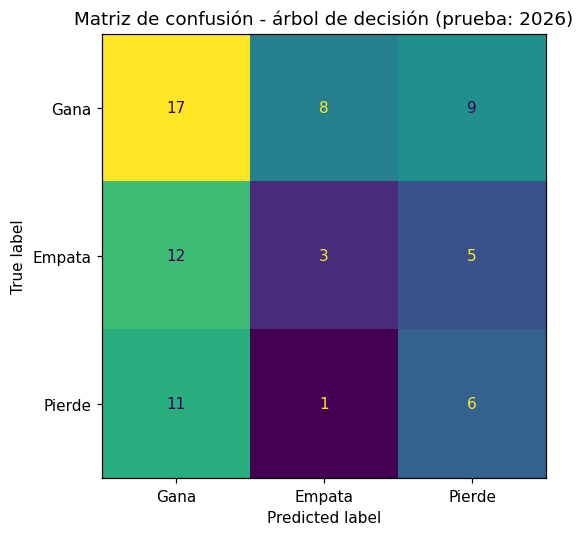

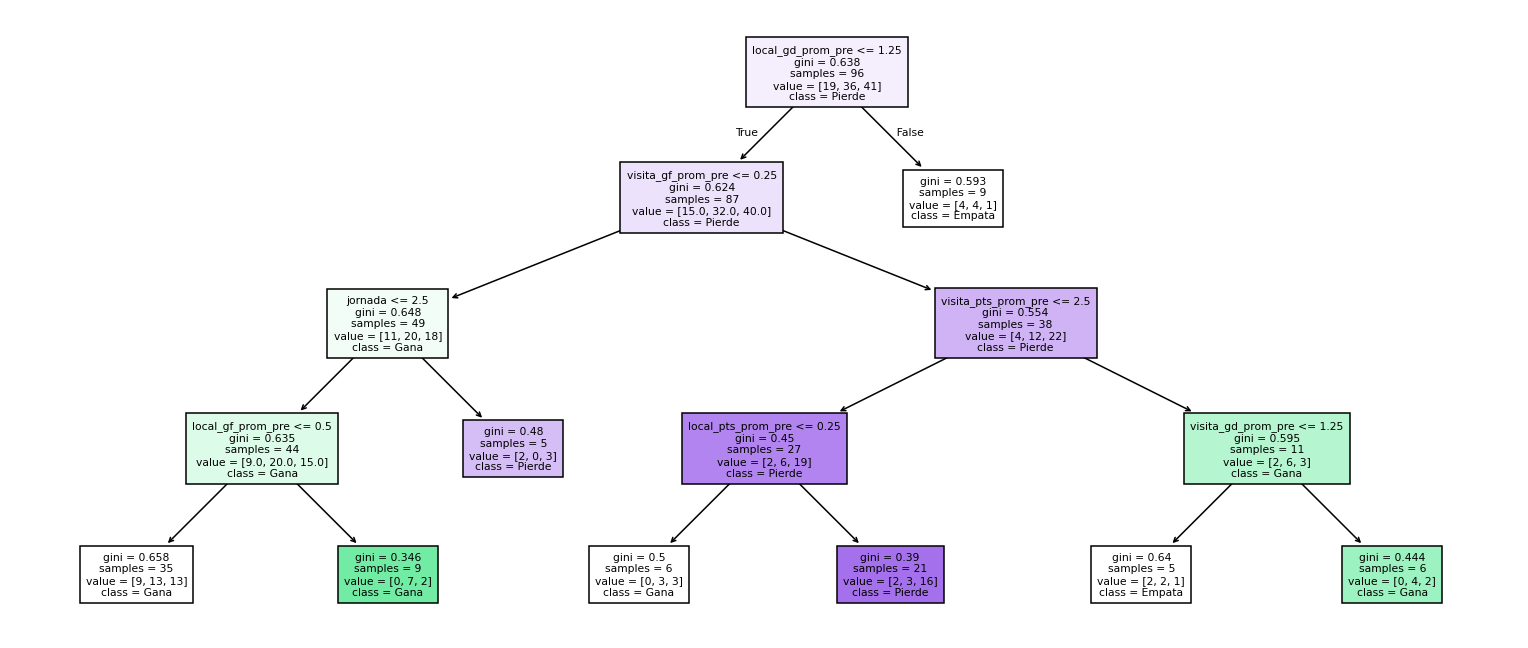

In [12]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre', 'visita_gd_prom_pre',
    'local_gf_prom_pre', 'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]

train = features_df[features_df['mundial'].isin([2018, 2022])]
test = features_df[features_df['mundial'] == 2026]

Xtr, ytr = train[features], train['resultado_local']
Xte, yte = test[features], test['resultado_local']

print('Tamaño entrenamiento (2018+2022):', len(Xtr))
print('Tamaño prueba (2026):', len(Xte))

linea_base = ytr.value_counts(normalize=True).idxmax()
acc_base = (yte == linea_base).mean()
print(f"\nLínea base: predecir siempre '{linea_base}' -> accuracy en 2026 = {acc_base:.3f}")

clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)
acc = accuracy_score(yte, pred)
print(f"Árbol de decisión -> accuracy en 2026 = {acc:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(yte, pred, labels=['Gana', 'Empata', 'Pierde'], ax=ax, colorbar=False)
ax.set_title('Matriz de confusión - árbol de decisión (prueba: 2026)')
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(14, 6))
plot_tree(clf, feature_names=features, class_names=clf.classes_, filled=True, fontsize=7, ax=ax2)
plt.tight_layout()
plt.show()

## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.

In [13]:
features_fuga = features + ['goles_local', 'goles_visitante', 'diferencia_goles']
Xtr_fuga, Xte_fuga = train[features_fuga], test[features_fuga]

clf_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf_fuga.fit(Xtr_fuga, ytr)
pred_fuga = clf_fuga.predict(Xte_fuga)
acc_fuga = accuracy_score(yte, pred_fuga)

print(f"Accuracy SIN fuga (variables previas al partido): {acc:.3f}")
print(f"Accuracy CON fuga (incluye goles_local/goles_visitante/diferencia_goles): {acc_fuga:.3f}")
print()
print("La diferencia_goles determina el resultado_local por definición (>0 Gana, =0 Empata, <0 Pierde),")
print("y goles_local/goles_visitante son el resultado final del propio partido: el modelo no está")
print("'prediciendo' nada, solo está leyendo la respuesta que se le dio como variable de entrada.")
print("Una precisión cercana al 100% con estas variables es la señal clásica de fuga de información,")
print("no una mejora real del modelo.")

Accuracy SIN fuga (variables previas al partido): 0.361
Accuracy CON fuga (incluye goles_local/goles_visitante/diferencia_goles): 1.000

La diferencia_goles determina el resultado_local por definición (>0 Gana, =0 Empata, <0 Pierde),
y goles_local/goles_visitante son el resultado final del propio partido: el modelo no está
'prediciendo' nada, solo está leyendo la respuesta que se le dio como variable de entrada.
Una precisión cercana al 100% con estas variables es la señal clásica de fuga de información,
no una mejora real del modelo.


## Reflexión final

Responde:

- ¿Qué problema de calidad fue el más difícil?
- ¿Qué decisión de limpieza podría cambiar los resultados?
- ¿Por qué 2026 debe compararse mediante tasas?
- ¿El árbol supera la línea base?
- ¿Qué variables reales agregarías para mejorar una predicción?
- ¿Por qué un resultado de 100 % puede ser una señal de alarma?

### Respuestas de ejemplo (compáralas con las tuyas, no las copies literalmente)

- **Problema más difícil**: unificar los tres esquemas de columnas y separar los marcadores con símbolos distintos (`-`, `–`, `—`, `:`, `x`), porque un mismo criterio debía funcionar para texto con o sin errores tipográficos.
- **Decisión que más cambiaría los resultados**: la regla "el marcador manda sobre los goles separados cuando ambos existen". Si se invirtiera la prioridad, algunos partidos cambiarían de resultado (por ejemplo, cuando un gol aparece como negativo o como texto).
- **Por qué comparar 2026 con tasas**: 2026 tiene 72 partidos (48 equipos, 12 grupos) contra 48 de 2018 y 2022 (32 equipos, 8 grupos); comparar goles totales exagera la diferencia solo por el tamaño del torneo, no por que se juegue "mejor" fútbol.
- **¿El árbol supera la línea base?**: sí, aunque por poco (accuracy del árbol ≈ 0.36 vs. línea base ≈ 0.25 en este experimento); con tan pocos partidos de entrenamiento (96) el margen real de mejora es limitado.
- **Variables reales que ayudarían**: ranking FIFA antes del torneo, valor de mercado o calidad del plantel, resultados en clasificatorias, lesiones de jugadores clave, si el equipo es local del torneo.
- **Por qué un 100% de accuracy es alarma**: si el modelo usa `goles_local`, `goles_visitante` o `diferencia_goles` como entrada, estas variables *son* (o determinan matemáticamente) la etiqueta que se quiere predecir. El modelo no aprendió a pronosticar: solo aprendió a leer la respuesta que se le entregó como dato de entrada (fuga de información).